# 01. Extracellular stimulation and recording

In this tutorial, we will explore how to use AxonML to simulate extracellular stimulation and recording in neuronal models. We will cover the following topics:

- Computing extracellular stimulation potentials
- Applying extracellular stimulation to neuronal populations
- Recording extracellular potentials from neuronal populations


## General principles

AxonML treats extracellular stimulation and recording in terms of the **extracellular potential** experienced by each model compartment. Conceptually, you should think of there being a value
$\phi_e(x_i, t_n)$
for **every compartment** $x_i$ and **every timestep** $t_n$. 

The stimulation machinery in AxonML is essentially about specifying and evaluating this field $\phi_e(x, t)$ over space and time, then feeding those values into the cable equations (which may themselves include multiple extracellular layers, e.g. for myelinated fibers).

### Quasistatic fields and separation of space and time

In typical neural-interface settings, electrode currents are relatively low frequency (up to a few kHz) and the spatial scale of interest is small compared to the speed of electromagnetic propagation. Under these conditions, the **quasistatic approximation** is appropriate: the spatial pattern of the extracellular potential adjusts essentially instantaneously to changes in electrode current, and displacement currents can be neglected.

Practically, this means we can separate the field into:

- a **spatial component** (a “lead field”) that depends only on position, and  
- a **temporal component** that depends only on the stimulation waveform.

For a single stimulating electrode, we can write
```{math}
\phi_e(x, t) \approx I(t)\,\Phi(x),
```
where:

- $\Phi(x)$ is the extracellular potential distribution produced by a **unit** current at that electrode (from an analytic solution or FEM), and  
- $I(t)$ is the time-varying current waveform delivered by the stimulator.

For multiple electrodes, this generalizes to
```{math}
\phi_e(x, t) = \sum_e I_e(t)\,\Phi_e(x),
```
where each $\Phi_e(x)$ is the unit-current field for electrode $e$.

In AxonML, this is exactly how **field objects** are used: you provide a spatial solution (or analytic expression) for unit input, and then drive it with one or more time-varying waveforms. Internally, AxonML evaluates $\phi_e(x_i, t_n)$ for every compartment and timestep without requiring you to recompute the field solution when you change the waveform.

### Reciprocity and extracellular recording

The same volume-conductor physics applies to extracellular recording. Under linear, quasistatic conditions, we can use **reciprocity**: the sensitivity of a recording electrode to a given membrane current source is the same as the extracellular potential that source would experience if we injected unit current at the recording site.

If $\Phi_{\text{rec}}(x)$ denotes the potential field generated by a **unit current at the recording electrode**, then the recorded signal can be written schematically as
```{math}
V_{\text{rec}}(t) = \sum_i \Phi_{\text{rec}}(x_i)\, I_m(x_i, t),
```
where $I_m(x_i, t)$ is the transmembrane current at compartment $x_i$.

In AxonML, this corresponds to using a “recording lead field” to weight the membrane currents from each compartment and sum them into a simulated local field potential or extracellular trace.

In summary:

- **Stimulation** is modeled by **imposing** $\phi_e(x_i, t_n)$ per compartment and timestep, using precomputed spatial fields scaled by time-varying waveforms.  
- **Recording** is modeled by **reading out** a weighted sum of membrane currents, using reciprocity-based lead fields for the recording electrode.

The rest of this tutorial will show how to construct these fields, attach them to neuronal populations, and use AxonML to simulate both extracellular stimulation and recording.


## Example: Extracellular kHz stimulation and recording

We will simulate a single myelinated axon model receiving extracellular kHz stimulation from a point source electrode, while recording the extracellular potential at another nearby point.

In [1]:
import axonml as ax
from axonml.models.mod import hh
from axonml.units import mm, um

model = ax.Myelinated(
    diameters=[6.0], n_node=201, node_length=1.0, celsius=6.3, v_init=-65.0
)
model.insert(hh)

The default `Myelinated` class assumes the well established heuristic that nodes of Ranvier are the only excitable compartments, with myelinated segments being fully insulated. This is a simplification, but it allows us to focus on the extracellular stimulation and recording aspects without needing to implement a full myelin model. It also implements the stadard heuristic that the internodal length is 100x the fiber diameter, so we can see that the model nodes of Ranvier span from -60 mm to +60 mm for a 6 μm fiber with 201 nodes:

In [2]:
print(model.x)

tensor([[-60000.0000, -59400.0000, -58800.0000, -58200.0000, -57600.0000,
         -57000.0000, -56400.0000, -55800.0000, -55200.0000, -54600.0000,
         -54000.0000, -53400.0000, -52800.0000, -52200.0000, -51600.0000,
         -51000.0000, -50400.0000, -49800.0000, -49200.0000, -48600.0000,
         -48000.0000, -47400.0000, -46800.0000, -46200.0000, -45600.0000,
         -45000.0000, -44400.0000, -43800.0000, -43200.0000, -42600.0000,
         -42000.0000, -41400.0000, -40800.0039, -40200.0039, -39600.0000,
         -39000.0000, -38400.0000, -37800.0000, -37200.0000, -36600.0000,
         -36000.0000, -35400.0000, -34800.0000, -34200.0000, -33600.0000,
         -33000.0000, -32400.0000, -31800.0000, -31200.0000, -30600.0000,
         -30000.0000, -29400.0000, -28800.0000, -28200.0000, -27600.0000,
         -27000.0000, -26400.0000, -25800.0039, -25200.0039, -24600.0039,
         -24000.0059, -23400.0000, -22800.0000, -22200.0000, -21600.0000,
         -21000.0000, -20400.0020, -19

We need to supply the extracellular potential fields for both stimulation and recording. For simplicity, we will use the analytic solution for a point source in an infinite homogeneous medium. AxonML's point source field generator makes this easy, calculating voltage in mV for a 1 mA current. The default resistivity is 500 Ω·cm, but you can change this with the `rhoe` argument if desired.

In [3]:
stim_source = ax.isotropic_point(z=200.0 * um, x=-40.0 * mm)
rec_source = ax.isotropic_point(z=200.0 * um, x=40.0 * mm)

For starters, lets just do stimulation:

In [4]:
from axonml.units import mA, kHz

ve_stim = stim_source(model)
i_stim = ax.sin(amp=0.05 * mA, freq=1.0 * kHz)  # 0.05 mA, 1 kHz sine wave
rec = ax.callbacks.Recorder(['v'], node_indices=model.c(0.16, 0.5, 0.75, 1.0))

tstop, dt = 50.0, 0.001

# run as before, but supply extracellular potential for stimulation
rec.reset()
model.initialize()
model.longrun(tstop=tstop, dt=dt, chunklength=100, extra=(ve_stim, i_stim), callbacks=[rec])

0.0 ms:   0%|          | 0/500 [00:00<?, ?it/s]

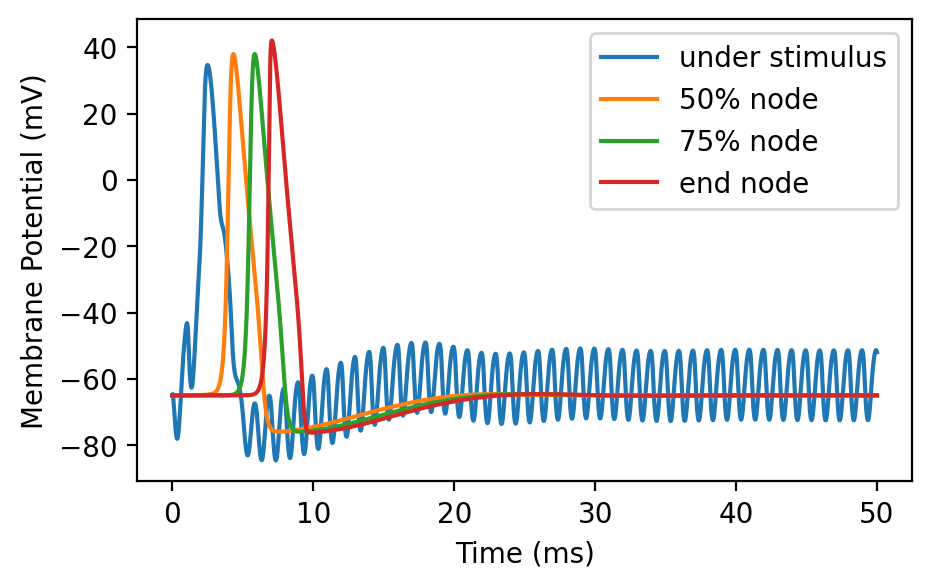

In [5]:
import matplotlib.pyplot as plt
import numpy as np

v = rec.numpy('v')
t = np.arange(0, tstop+dt, dt)

plt.figure(figsize=(5, 3), dpi=200)
plt.plot(t, v[:, 0, 0], label="under stimulus")
plt.plot(t, v[:, 0, 1], label="50% node")
plt.plot(t, v[:, 0, 2], label="75% node")
plt.plot(t, v[:, 0, 3], label="end node")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.show()

Ok great! We have the extracellular potential field set up for stimulation. We see that this particular stimulation configuration has an onset response and then not much else (at least not within the first 50 ms). Next, we can record some LFP data using the `LFP` callback:

In [6]:
v_rec = rec_source(model)
lfp_rec = ax.callbacks.LFP([v_rec])

lfp_rec.reset()
model.initialize()
model.longrun(tstop=tstop, dt=dt, chunklength=100, extra=(ve_stim, i_stim), callbacks=[lfp_rec])

0.0 ms:   0%|          | 0/500 [00:00<?, ?it/s]

RuntimeError: Model must be compiled with IMEM=1. Use with ax.ctx(IMEM=1): model = ...

Ah an error! For LFP recording, we need to provide the transmembrane currents as well. To do this, we need to instruct the model to compute and store these currents during the simulation:

In [7]:
with ax.ctx(IMEM=1):
    model = ax.Myelinated(
        diameters=[6.0], n_node=201, node_length=1.0, celsius=6.3, v_init=-65.0
    )
    
# then same as before
model.insert(hh)

v_rec = rec_source(model)
lfp_rec = ax.callbacks.LFP([v_rec])

lfp_rec.reset()
model.initialize()
model.longrun(
    tstop=tstop, 
    dt=dt, 
    chunklength=100, 
    extra=(ve_stim, i_stim), 
    callbacks=[lfp_rec]
)


0.0 ms:   0%|          | 0/500 [00:00<?, ?it/s]

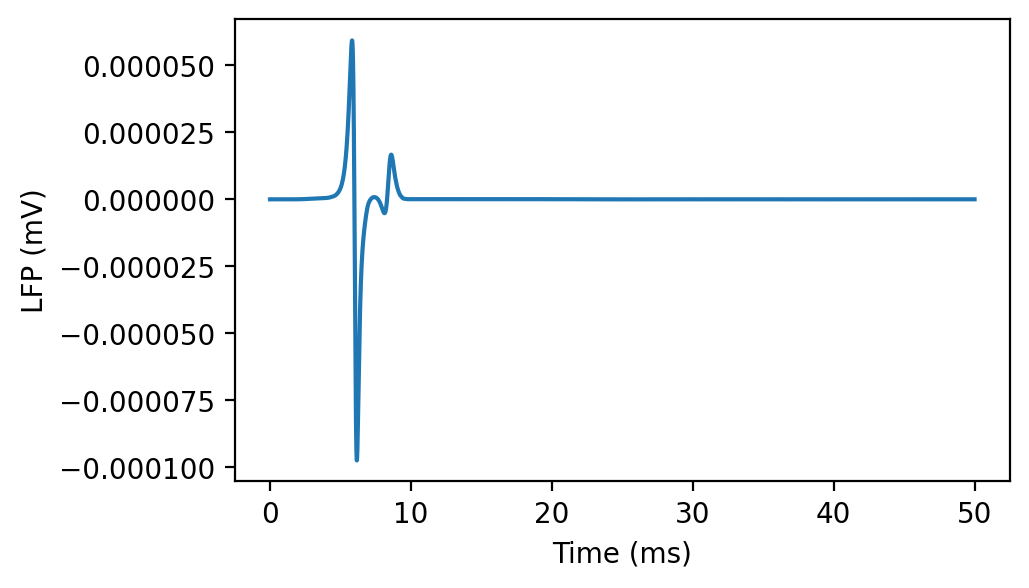

In [8]:
plt.figure(figsize=(5, 3), dpi=200)
plt.plot(t, lfp_rec.numpy()[:, 0])
plt.xlabel("Time (ms)")
plt.ylabel("LFP (mV)")
plt.show()

## Stimulating and recording from a population

Now that we have the basic extracellular stimulation and recording working for a single axon, we can easily extend this to a population of axons. We will create a population of 100 myelinated axons arranged in a grid, and apply the same extracellular stimulation and recording setup as before.

In [9]:

import torch

diameters = np.random.uniform(5.0, 10.0, size=100)

with ax.ctx(IMEM=1):
    model = ax.Myelinated(
        diameters=diameters, n_node=201, node_length=1.0, celsius=6.3, v_init=-65.0
    )
    
# then same as before
model.insert(hh)

# add some random spatial offsets to each axon
x_offsets = -50.0 + 100.0 * torch.rand(100)
y_offsets = -20.0 + 40.0 * torch.rand(100)
z_offsets = -20.0 + 40.0 * torch.rand(100)
model.x += x_offsets[:, None]
model.y += y_offsets[:, None]
model.z += z_offsets[:, None]

v_stim = stim_source(model)
v_rec = rec_source(model)
lfp_rec = ax.callbacks.LFP([v_rec])

lfp_rec.reset()
model.initialize()
model.longrun(
    tstop=tstop, 
    dt=dt, 
    chunklength=100, 
    extra=(v_stim, i_stim), 
    callbacks=[lfp_rec]
)

0.0 ms:   0%|          | 0/500 [00:00<?, ?it/s]

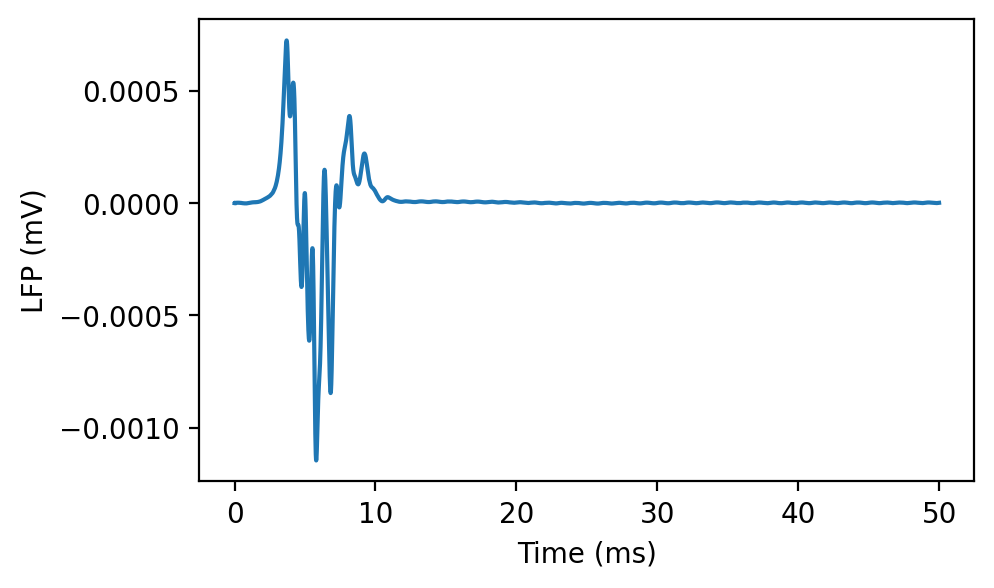

In [10]:
plt.figure(figsize=(5, 3), dpi=200)
plt.plot(t, lfp_rec.numpy()[:, 0])
plt.xlabel("Time (ms)")
plt.ylabel("LFP (mV)")
plt.show()

Great! To summarize, we have successfully set up extracellular stimulation and recording for a population of myelinated axons using AxonML. We created a population of axons with random diameters and spatial offsets, applied point source stimulation, and recorded the resulting extracellular potentials. Next, you can experiment with different stimulation parameters, electrode configurations, and axon properties to explore their effects on the recorded signals. In the next tutorial, we will look into branched neuron models and how to apply extracellular stimulation and recording to them.